In [1]:
pip install tiktoken matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import math
import torch
import tiktoken
from datasets.preprocess import download_the_verdict
from datasets.dataloader import create_dataloader
from evaluation.loss import  cross_entropy_loss
from trainer.trainer import train_simple_model
from models.gpt2 import GPT
from configs.model import ModelConfig
from configs.training import TrainingConfig
from evaluation.loss import calc_loss_accuracy_loader,cross_entropy_loss
from generation.sample_text import generate_sample_text

In [2]:
tokenizer = tiktoken.get_encoding("gpt2")

In [3]:
GPT2_SMALL = ModelConfig(
    emb_dim=32,
    n_layers=2,
    n_heads=4,
    activation="gelu",
    context_length=24
)

TRAIN_CONFIG = TrainingConfig(
    epochs=1,
    batch_size=2,
    stride=24,
    context_length=24
)


In [4]:
raw_text = download_the_verdict()
train_data = 0.9  ## train data to be 90%
len_train_data = math.floor(len(raw_text)* train_data)
train_data = raw_text[:len_train_data]
val_data = raw_text[len_train_data:] 


train_dataloader = create_dataloader(train_data, TRAIN_CONFIG)
val_dataloader = create_dataloader(val_data,TRAIN_CONFIG)

In [5]:
dataiter = iter(train_dataloader)
input_sample, target_sample = next(dataiter)
print(input_sample, target_sample)

tensor([[   40,   367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138,
           257,  7026, 15632,   438,  2016,   257,   922,  5891,  1576,   438,
           568,   340,   373,   645],
        [ 1049,  5975,   284,   502,   284,  3285,   326,    11,   287,   262,
          6001,   286,   465, 13476,    11,   339,   550,  5710,   465, 12036,
            11,  6405,   257,  5527]]) tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138,   257,
          7026, 15632,   438,  2016,   257,   922,  5891,  1576,   438,   568,
           340,   373,   645,  1049],
        [ 5975,   284,   502,   284,  3285,   326,    11,   287,   262,  6001,
           286,   465, 13476,    11,   339,   550,  5710,   465, 12036,    11,
          6405,   257,  5527, 27075]])


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [7]:
model = GPT(GPT2_SMALL).to(device)

In [8]:
calc_loss_accuracy_loader(model,device,val_dataloader)

(np.float32(10.974073), tensor(0.))

In [9]:
output = model(input_sample)
print(output.shape)

torch.Size([2, 24, 50257])


In [10]:
with torch.no_grad():
    output = model(input_sample)
    loss = cross_entropy_loss(output, target_sample)
    print(loss)


tensor(11.0211)


In [11]:
epoch = 3
optimizer = torch.optim.AdamW(model.parameters(),lr=0.001)

In [12]:
torch.autograd.set_detect_anomaly(True)

In [13]:
from evaluation.metrics import Metrics
metrics = Metrics()

In [16]:
train_simple_model(epoch,model,device,metrics,tokenizer,train_dataloader,cross_entropy_loss,optimizer,val_dataloader)

after 1 epoch the train loss 9.85731315612793 val loss 7.691091537475586 and train acc| 0.01822916604578495 val acc| 0.0018939394503831863 
text generate after epoch 1 is Every effort moves you,,,,,,,,
after 2 epoch the train loss 6.585530757904053 val loss 6.743714809417725 and train acc| 0.039930559694767 val acc| 0.0 
text generate after epoch 2 is Every effort moves you
.
.




after 3 epoch the train loss 6.186474323272705 val loss 6.689177989959717 and train acc| 0.0403645858168602 val acc| 0.0 
text generate after epoch 3 is Every effort moves you










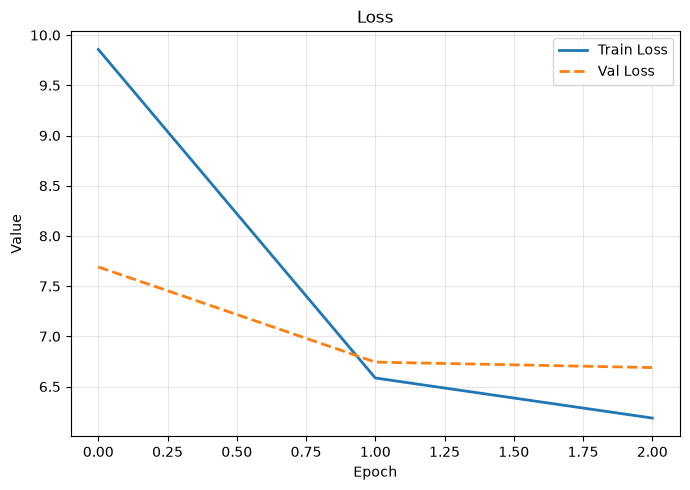

In [17]:
metrics.plot("train_loss", "val_loss")

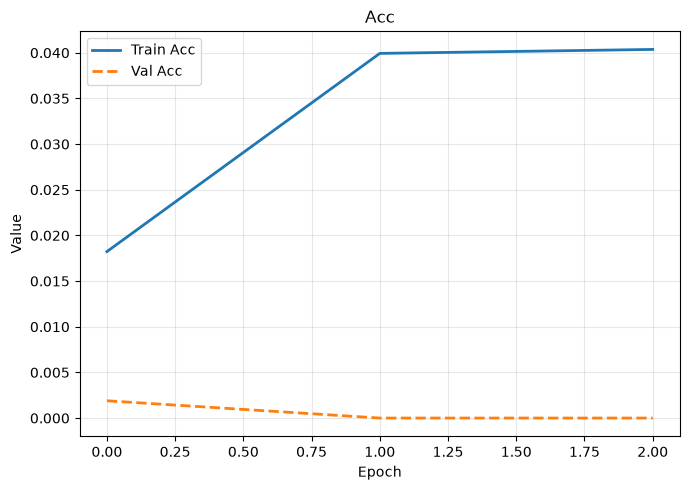

In [22]:
metrics.plot("train_acc", "val_acc")

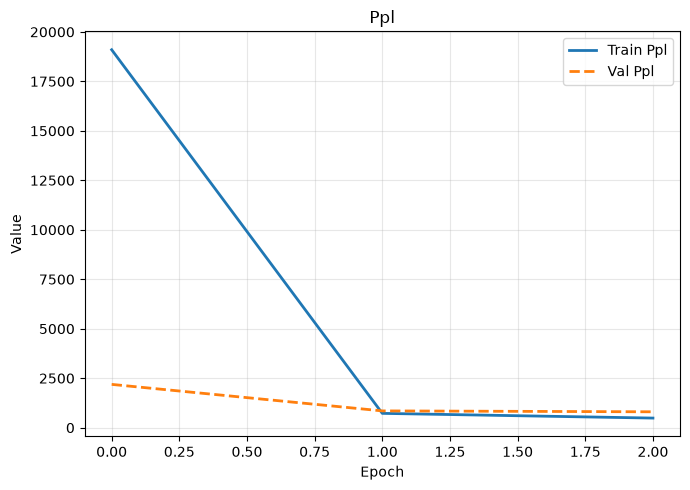

In [23]:
metrics.plot("train_ppl","val_ppl")

In [21]:
generate_sample_text(model, device, tokenizer, "Next day is",10)

'Next day is,,,,, the.\n\n\n'